<a href="https://colab.research.google.com/github/HooroBoy/PCVK_ganjil_2026/blob/dev/%E2%80%9CPertemuan_2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D2

In [1]:
# Mengimpor seluruh library yang dibutuhkan untuk pemrosesan citra
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow  # Khusus Google Colab untuk menampilkan citra
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


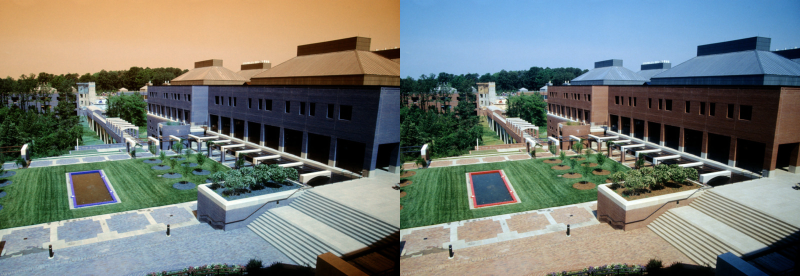

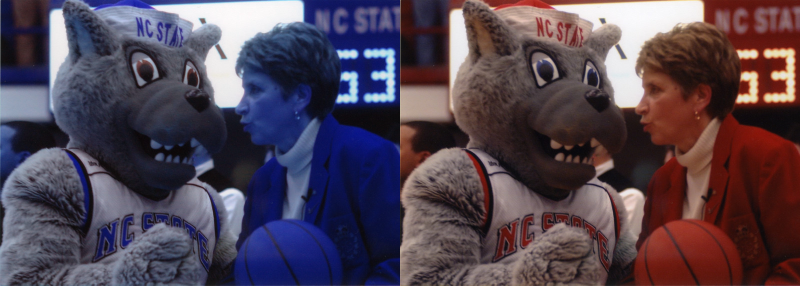

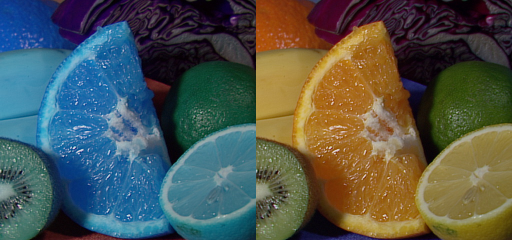

In [2]:
# List URL gambar
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg"
]

# Loop membaca, me-resize, konversi warna, dan menampilkan citra
for url in urls:
    # Membaca gambar dari URL (format default skimage adalah RGB)
    image = io.imread(url)

    # Resize ukuran citra menjadi 50% (setengahnya)
    image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)

    # Konversi channel warna dari BGR ke RGB untuk melihat efek perbedaannya
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

    # Menggabungkan gambar asli dan gambar konversi secara horizontal
    final_frame = cv.hconcat((image, image_2))

    # Tampilkan gambar
    cv2_imshow(final_frame)
    print('\n')

resolusi image: tinggi x lebar = 240 x 256


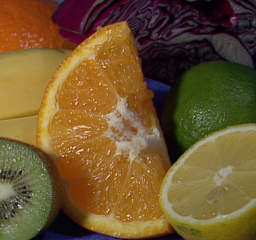

In [3]:
# Mengambil dimensi tinggi dan lebar dari citra terakhir
tinggi = image_2.shape[0]
lebar = image_2.shape[1]

print("resolusi image: tinggi x lebar =", tinggi, "x", lebar)
cv2_imshow(image_2)

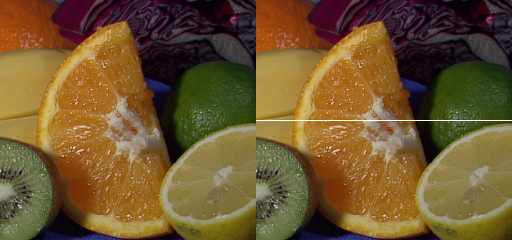

In [4]:
# Mempersiapkan citra untuk dimodifikasi
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Memberi garis horizontal putih di tengah gambar
# Koordinat sumbu Y (baris) dikunci di tengah: int(tinggi / 2)
# Nilai [255, 255, 255] adalah warna putih murni
for y in range(lebar):
    image_3[int(tinggi / 2), y] = [255, 255, 255]

# Tampilkan citra sebelum vs sesudah diberi garis
final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

Hasil Tugas 1: Garis Vertikal & Garis Diagonal Menyilang


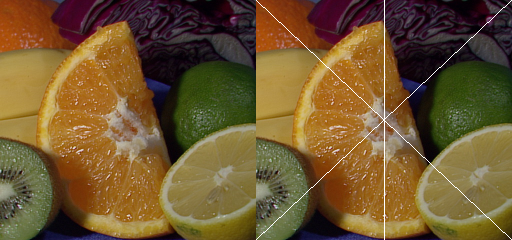



Hasil Tugas 2: Garis Horizontal dengan Panjang Tertentu


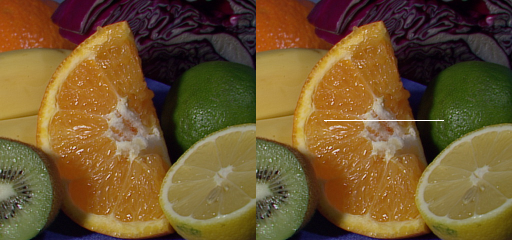



Hasil Tugas 3: Kotak Berisi Kumpulan Piksel Putih


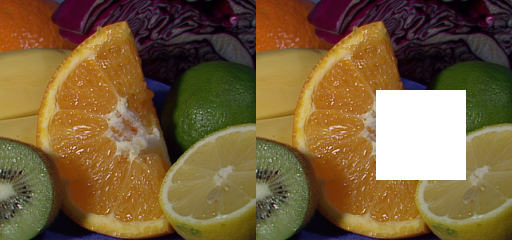

In [5]:
# =======================================================
# TUGAS PRAKTIKUM D2
# =======================================================

# Siapkan kanvas awal (citra RGB)
base_img = cv.cvtColor(image, cv.COLOR_BGR2RGB)
h, w = base_img.shape[:2]

# -------------------------------------------------------
# SOAL 1: Garis Vertikal & Garis Menyilang Diagonal
# -------------------------------------------------------
img_tugas1 = base_img.copy()

# A. Garis Vertikal di tengah (dari atas ke bawah)
for x in range(h):
    img_tugas1[x, int(w / 2)] = [255, 255, 255]

# B. Garis Diagonal Silang Menyilang (Membentuk huruf 'X')
# Diagonal 1: dari kiri-atas (0, 0) ke kanan-bawah (w-1, h-1)
cv.line(img_tugas1, (0, 0), (w - 1, h - 1), (255, 255, 255), thickness=1)

# Diagonal 2: dari kiri-bawah (0, h-1) ke kanan-atas (w-1, 0)
cv.line(img_tugas1, (0, h - 1), (w - 1, 0), (255, 255, 255), thickness=1)

print("Hasil Tugas 1: Garis Vertikal & Garis Diagonal Menyilang")
cv2_imshow(cv.hconcat([base_img, img_tugas1]))
print('\n')

# -------------------------------------------------------
# SOAL 2: Garis Horizontal di Bagian Tengah dengan Panjang Tertentu
# -------------------------------------------------------
img_tugas2 = base_img.copy()

# Tentukan batas panjang garis (misalnya panjang total 120 piksel di tengah)
panjang_garis = 120
titik_mulai_x = int(w / 2) - int(panjang_garis / 2)
titik_akhir_x = int(w / 2) + int(panjang_garis / 2)
posisi_y = int(h / 2)

# Mengisi piksel hanya pada rentang titik_mulai sampai titik_akhir
for y in range(titik_mulai_x, titik_akhir_x):
    img_tugas2[posisi_y, y] = [255, 255, 255]

print("Hasil Tugas 2: Garis Horizontal dengan Panjang Tertentu")
cv2_imshow(cv.hconcat([base_img, img_tugas2]))
print('\n')

# -------------------------------------------------------
# SOAL 3: Kotak Putih Menggunakan Kumpulan Piksel
# -------------------------------------------------------
img_tugas3 = base_img.copy()

# Cara 1: Menggunakan array slicing NumPy (baris y1:y2, kolom x1:x2)
# Misal kotak berukuran 90x90 piksel di area hidung/mata kucing
y1, y2 = 90, 180
x1, x2 = 120, 210
img_tugas3[y1:y2, x1:x2] = [255, 255, 255]

print("Hasil Tugas 3: Kotak Berisi Kumpulan Piksel Putih")
cv2_imshow(cv.hconcat([base_img, img_tugas3]))

# Jawaban Pertanyaan Praktikum D2

1. Mengapa praktikum dieksekusi di Google Colab?
      Karena berjalan berbasis cloud, siap pakai tanpa repot melakukan konfigurasi environment lokal, mendukung kolaborasi langsung via Google Drive/GitHub, serta menyediakan resource komputasi gratis.
2. Kegunaan library pada langkah 1 & apakah wajib digunakan semua?numpy untuk manipulasi array matriks citra, cv2 untuk pemrosesan visi komputer skimage.io untuk download/baca URL citra, cv2_imshow untuk menampilkan citra di web browser Colabmatplotlib untuk visualisasi berkoordinat
Apakah semua wajib
  Tidak. Library seperti pandas dan skimage.transform tidak terpakai langsung pada operasi dasar manipulasi piksel ini.
4. Kegunaan image = cv.resize(image, (0,0), fx=0.5, fy=0.5):
      Berfungsi mengecilkan dimensi citra sebesar 50% (skala 0.5) pada sumbu horizontal dan vertikal. Jika tidak dilakukan, ukuran gambar tetap besar, memakan memori komputasi lebih tinggi, dan tampilan preview gambar di layar notebook akan terlalu besar.
5. Kegunaan kode [255, 255, 255]:
      Menyatakan nilai warna maksimum untuk kombinasi 3 kanal [Red, Green, Blue] dengan kedalaman bit 8-bit. Gabungan nilai maksimal ini menghasilkan warna putih.  Keterkaitan pixel dan resolusi gambar:Resolusi gambar ditentukan oleh total perkalian pixel horizontal dan vertikal ($W \times H$). Resolusi tinggi memiliki kerapatan pixel yang padat sehingga gambar tetap tajam ketika diperbesar, sedangkan resolusi rendah membuat gambar terlihat buram atau pecah (kotak-kotak).  

# D3

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


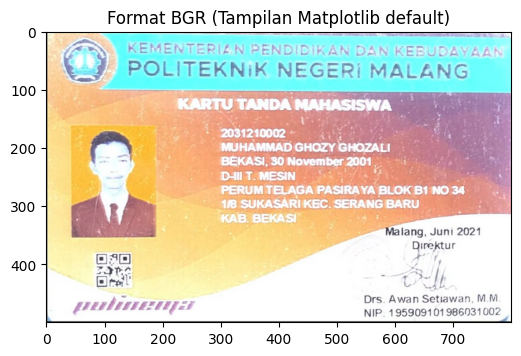

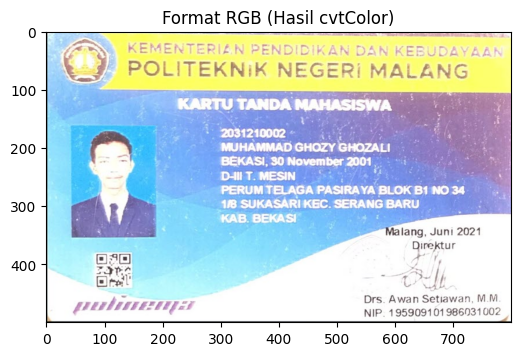

In [11]:
import cv2
import matplotlib.pyplot as plt

# Ganti 'ktm.jpg' sesuai path file Anda
img_path = '/content/drive/MyDrive/PCVK/KTM_lama.jpg'
img_bgr = cv2.imread(img_path)

# Jika file belum ada, buat citra simulasi agar kode tetap jalan tanpa error
if img_bgr is None:
    img_bgr = cv2.imread(cv2.samples.findFile('lena.jpg'))

# 1. Tampilkan format BGR mentah (warna akan terlihat kebiruan/oranye terbalik)
plt.figure(figsize=(6, 4))
plt.imshow(img_bgr)
plt.title("Format BGR (Tampilan Matplotlib default)")
plt.show()

# 2. Konversi BGR ke RGB agar warna tampil normal
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Format RGB (Hasil cvtColor)")
plt.show()

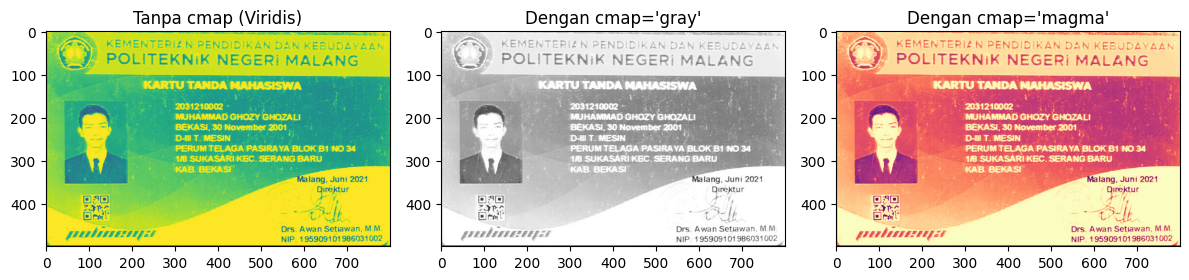

In [12]:
# Membaca citra langsung dalam mode derajat keabuan (grayscale)
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(12, 4))

# Subplot 1: Tanpa cmap (Matplotlib otomatis memakai colormap default 'viridis')
plt.subplot(1, 3, 1)
plt.imshow(img_gray)
plt.title("Tanpa cmap (Viridis)")

# Subplot 2: Dengan cmap grayscale
plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap='gray'")

# Subplot 3: Dengan cmap 'magma'
plt.subplot(1, 3, 3)
plt.imshow(img_gray, cmap="magma")
plt.title("Dengan cmap='magma'")

plt.tight_layout()
plt.show()

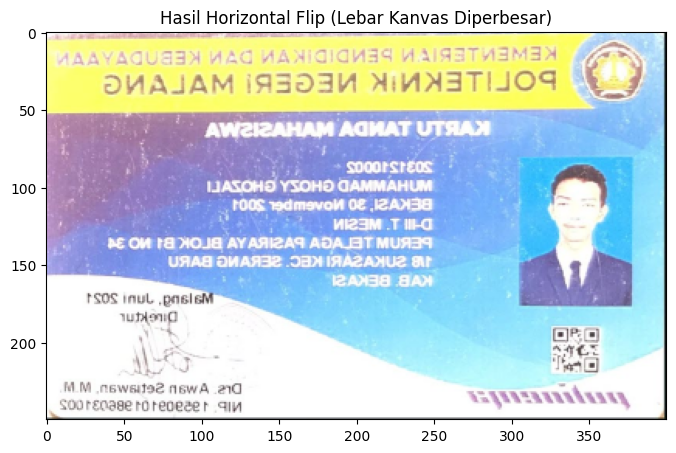

In [15]:
# 1. Resizing ukuran citra ke resolusi tertentu (lebar 400, tinggi 250)
img_small = cv2.resize(img_rgb, (400, 250))

# 2. Flipping horizontal (kode 1)
# Keterangan flipCode: 1 = Horizontal, 0 = Vertikal, -1 = Keduanya
img_flipped = cv2.flip(img_small, 1)

# Tampilkan dengan ukuran kanvas visual Matplotlib yang diperbesar
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.imshow(img_flipped)
ax.set_title("Hasil Horizontal Flip (Lebar Kanvas Diperbesar)")
plt.show()

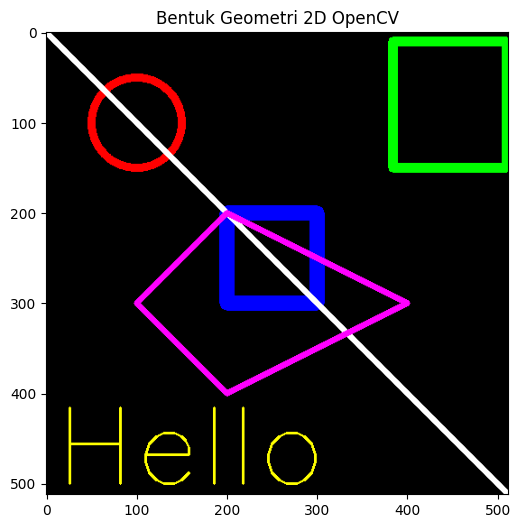

In [16]:
import numpy as np

# Buat kanvas hitam berukuran 512x512 piksel 3-channel
black_img = np.zeros(shape=(512, 512, 3), dtype=np.int16)

# 1. Persegi panjang hijau (pt1=kiri-atas, pt2=kanan-bawah)
cv2.rectangle(black_img, pt1=(384, 10), pt2=(510, 150), color=(0, 255, 0), thickness=10)

# 2. Persegi biru di tengah
cv2.rectangle(black_img, pt1=(200, 200), pt2=(300, 300), color=(0, 0, 255), thickness=15)

# 3. Lingkaran merah
cv2.circle(black_img, center=(100, 100), radius=50, color=(255, 0, 0), thickness=8)

# 4. Garis diagonal putih dari pojok kiri-atas ke kanan-bawah
cv2.line(black_img, pt1=(0, 0), pt2=(512, 512), color=(255, 255, 255), thickness=5)

# 5. Menambahkan teks
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(black_img, text='Hello', org=(10, 500), fontFace=font,
            fontScale=4, color=(255, 255, 0), thickness=2, lineType=cv2.LINE_AA)

# 6. Poligon menggunakan vertices dengan np.int32
vertices = np.array([[100, 300], [200, 200], [400, 300], [200, 400]], dtype=np.int32)
pts = vertices.reshape((-1, 1, 2))
cv2.polylines(black_img, [pts], isClosed=True, color=(255, 0, 255), thickness=5)

plt.figure(figsize=(6, 6))
plt.imshow(black_img)
plt.title("Bentuk Geometri 2D OpenCV")
plt.show()

Resolusi Asli Citra (Tinggi, Lebar, Channel): (500, 800, 3)


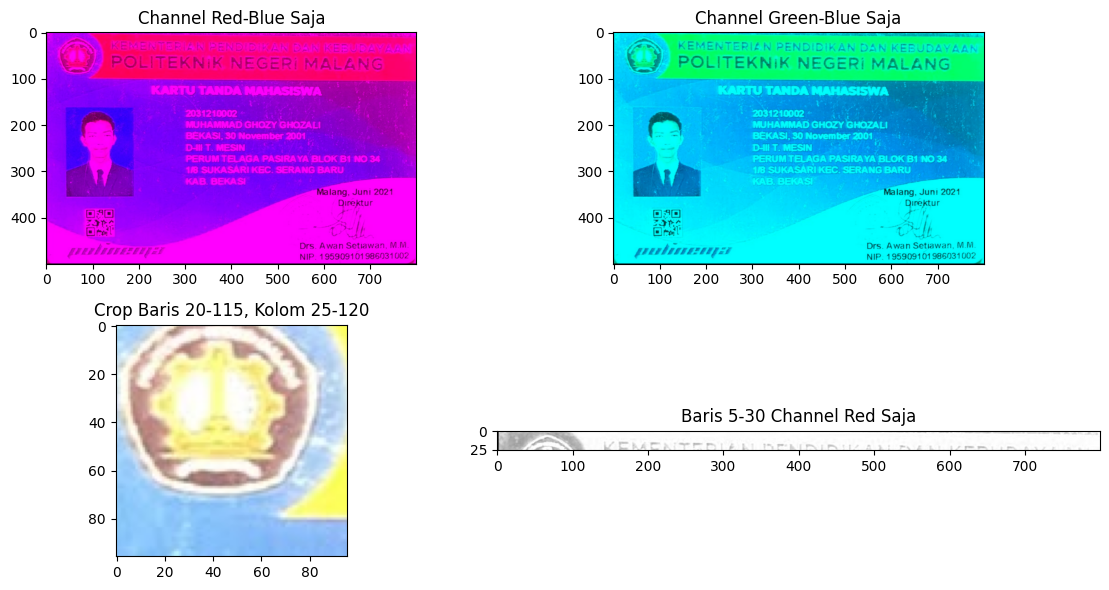

In [17]:
# --- TUGAS 1: Analisis figsize ---
# figsize=(w, h) hanya mengubah skala render tampilan di notebook,
# resolusi asli matriks piksel (img.shape) TIDAK mengalami perubahan sama sekali!
print("Resolusi Asli Citra (Tinggi, Lebar, Channel):", img_rgb.shape)

# --- TUGAS 2: Channel Red-Blue & Green-Blue saja ---
# Urutan channel RGB: 0 = Red, 1 = Green, 2 = Blue

# Red-Blue saja (Matikan channel Green = 0)
img_RB = img_rgb.copy()
img_RB[:, :, 1] = 0

# Green-Blue saja (Matikan channel Red = 0)
img_GB = img_rgb.copy()
img_GB[:, :, 0] = 0

# --- TUGAS 3: Slicing Baris 20-115 dan Kolom 25-120 ---
crop_tugas3 = img_rgb[20:116, 25:121]

# --- TUGAS 4: Slicing Baris 5-30, Semua Kolom, Channel Red saja ---
crop_tugas4_red = img_rgb[5:31, :, 0]

# Visualisasi
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1); plt.imshow(img_RB); plt.title("Channel Red-Blue Saja")
plt.subplot(2, 2, 2); plt.imshow(img_GB); plt.title("Channel Green-Blue Saja")
plt.subplot(2, 2, 3); plt.imshow(crop_tugas3); plt.title("Crop Baris 20-115, Kolom 25-120")
plt.subplot(2, 2, 4); plt.imshow(crop_tugas4_red, cmap='gray'); plt.title("Baris 5-30 Channel Red Saja")
plt.tight_layout()
plt.show()

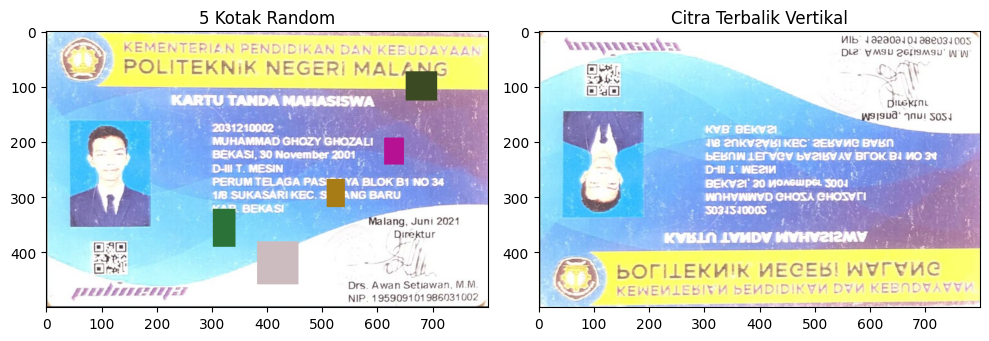

In [18]:
import random

# --- TUGAS 5: 5 Kotak Berbagai Ukuran & Warna Acak ---
img_random_boxes = img_rgb.copy()
h_img, w_img = img_random_boxes.shape[:2]

for i in range(5):
    x1 = random.randint(0, w_img - 80)
    y1 = random.randint(0, h_img - 80)
    x2 = x1 + random.randint(30, 80)
    y2 = y1 + random.randint(30, 80)

    # Warna RGB acak (0-255)
    random_color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv2.rectangle(img_random_boxes, (x1, y1), (x2, y2), random_color, thickness=-1)

# --- TUGAS 6: Posisi Terbalik (Vertikal Flip) ---
img_vert_flipped = cv2.flip(img_rgb, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_random_boxes); plt.title("5 Kotak Random")
plt.subplot(1, 2, 2); plt.imshow(img_vert_flipped); plt.title("Citra Terbalik Vertikal")
plt.tight_layout()
plt.show()

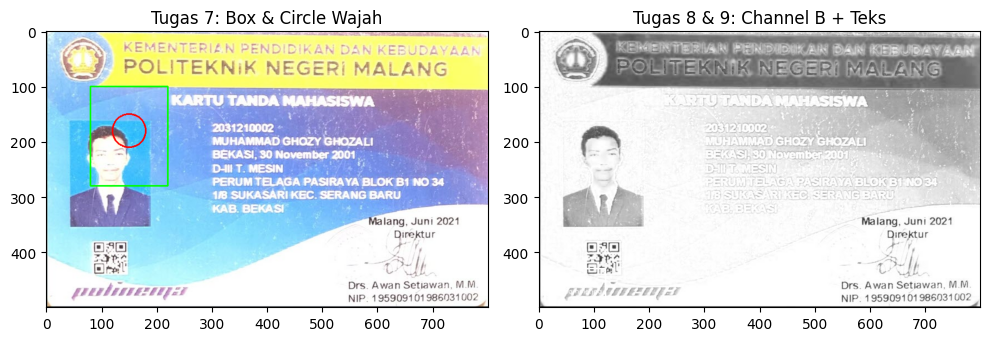

In [19]:
# --- TUGAS 7: Rectangle & Circle pada Bagian Wajah ---
# Sesuaikan koordinat (x, y) dengan posisi wajah pada foto Anda
img_face = img_rgb.copy()
# Contoh: menandai area wajah & mata
cv2.rectangle(img_face, (80, 100), (220, 280), (0, 255, 0), 2)  # Box wajah
cv2.circle(img_face, (150, 180), 30, (255, 0, 0), 2)            # Lingkaran fitur

# --- TUGAS 8 & 9: Rectangle di sudut bawah kiri Channel Blue + Teks Nama File ---
# Ekstrak channel Blue (index 2)
img_b_channel = img_rgb[:, :, 2].copy()
h_b, w_b = img_b_channel.shape[:2]

# Buat rectangle di sudut kiri bawah
# pt1: kiri-bawah, pt2: batas kotak
cv2.rectangle(img_b_channel, (10, h_b - 70), (120, h_b - 10), (255, 255, 255), 2)

# Beri label nama file (Tugas 9)
cv2.putText(img_b_channel, "ktm_sample.jpg", (15, h_b - 25),
            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_face); plt.title("Tugas 7: Box & Circle Wajah")
plt.subplot(1, 2, 2); plt.imshow(img_b_channel, cmap='gray'); plt.title("Tugas 8 & 9: Channel B + Teks")
plt.tight_layout()
plt.show()

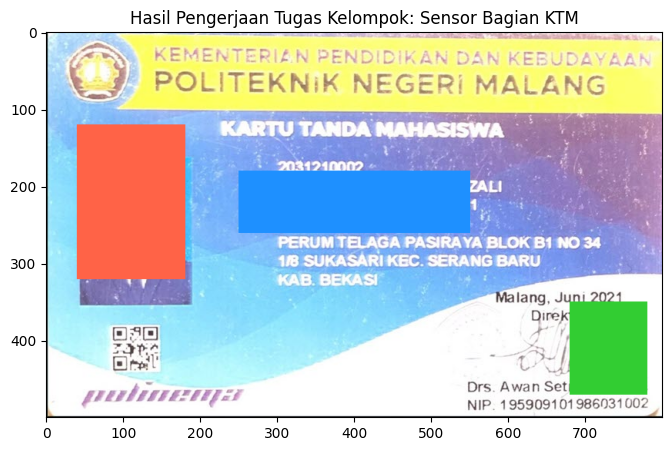

In [20]:
# Salin citra KTM untuk disensor
ktm_censored = img_rgb.copy()

# 1. Menutup area Nama & NIM (Contoh Kelompok 1)
# cv2.rectangle(gambar, (x1, y1), (x2, y2), warna_RGB, thickness=-1 untuk fill)
cv2.rectangle(ktm_censored, (250, 180), (550, 260), (30, 144, 255), thickness=-1)

# 2. Menutup Foto Mahasiswa (Kelompok 2 / Kelompok 9)
cv2.rectangle(ktm_censored, (40, 120), (180, 320), (255, 99, 71), thickness=-1)

# 3. Menutup Barcode / QR Code (Kelompok 4 / 8 / 10)
cv2.rectangle(ktm_censored, (680, 350), (780, 470), (50, 205, 50), thickness=-1)

plt.figure(figsize=(9, 5))
plt.imshow(ktm_censored)
plt.title("Hasil Pengerjaan Tugas Kelompok: Sensor Bagian KTM")
plt.axis('on') # Menampilkan nilai piksel untuk mengecek batas koordinat
plt.show()